In [8]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. LOAD AND PREPARE DATASET
# ============================================================

# Load the dataset generated after the new EDA
df = pd.read_csv('../data/processed/dataset_modeling.csv')

TARGET = 'uhi_risk'

# Identify categorical and numerical features based on the new EDA
FEATURES = [
    'latitude', 'longitude', 'elevation', 
    'mndwi', 'nbr', 'ndbi', 'ndmi', 'ndvi', 'ndwi', 'nir', 'swir1', 'swir2',
    'season'
]

# Drop target and split features
X = df[FEATURES]
y = df[TARGET]

# ============================================================
# 2. ENCODE CATEGORICAL VARIABLES (One-Hot Encoding)
# ============================================================

# XGBoost cannot handle string arrays natively. We convert the 'season' column
# into binary columns (dummy variables). drop_first=True reduces dummy variable trap.
X = pd.get_dummies(X, columns=['season'], drop_first=True)

# Update the feature list to account for the new one-hot encoded columns
UPDATED_FEATURES = X.columns.tolist()



In [9]:
# ============================================================
# 3. TRAIN-TEST SPLIT
# ============================================================

# Stratified split ensures the 0 and 1 distribution matches exactly between sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training dimensions : {X_train.shape[0]:,}")
print(f"Testing dimensions  : {X_test.shape[0]:,}")



Training dimensions : 55,746
Testing dimensions  : 13,937


[0]	validation_0-logloss:0.68464
[100]	validation_0-logloss:0.54610
[200]	validation_0-logloss:0.54067
[300]	validation_0-logloss:0.53891
[400]	validation_0-logloss:0.53845
[454]	validation_0-logloss:0.53851

BASELINE REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

   no_riesgo       0.71      0.68      0.70      6613
      riesgo       0.72      0.75      0.74      7324

    accuracy                           0.72     13937
   macro avg       0.72      0.72      0.72     13937
weighted avg       0.72      0.72      0.72     13937

Baseline AUC-ROC: 0.8007


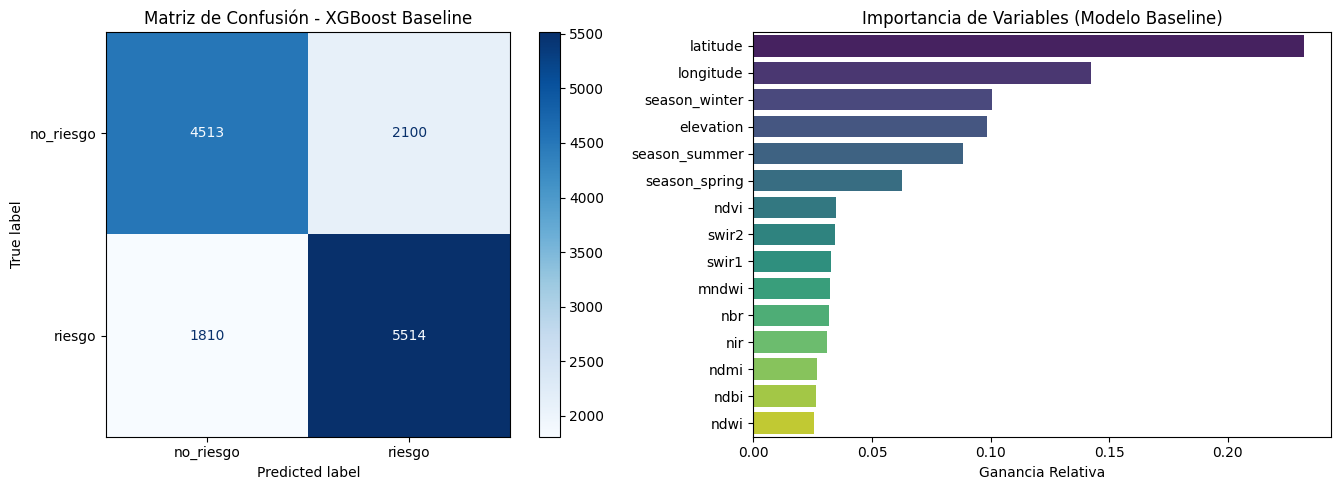

In [12]:
# ============================================================
# 4. BASE MODEL INITIALIZATION & TRAINING
# ============================================================

# We set up an initial baseline using early stopping to prevent overfitting.
xgb_baseline = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    early_stopping_rounds=50
)

xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Baseline Evaluation
y_pred_base = xgb_baseline.predict(X_test)
y_probs_base = xgb_baseline.predict_proba(X_test)[:, 1]

print("\n" + "="*55)
print("BASELINE REPORTE DE CLASIFICACIÓN")
print("="*55)
print(classification_report(y_test, y_pred_base, target_names=["no_riesgo", "riesgo"]))
print(f"Baseline AUC-ROC: {roc_auc_score(y_test, y_probs_base):.4f}")

# ============================================================
# VISUALIZATION (BASELINE MODEL)
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix for Baseline
cm_base = confusion_matrix(y_test, y_pred_base)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=["no_riesgo", "riesgo"])
disp_base.plot(ax=ax[0], cmap="Blues", values_format="d")
ax[0].set_title("Matriz de Confusión - XGBoost Baseline")

# Feature Importance for Baseline
importances_base = xgb_baseline.feature_importances_
indices_base = np.argsort(importances_base)[::-1]

sns.barplot(x=importances_base[indices_base], y=np.array(UPDATED_FEATURES)[indices_base], ax=ax[1], palette="viridis")
ax[1].set_title("Importancia de Variables (Modelo Baseline)")
ax[1].set_xlabel("Ganancia Relativa")

plt.tight_layout()
plt.show()



Iniciando optimización por búsqueda aleatoria...
Fitting 4 folds for each of 10 candidates, totalling 40 fits



Mejores parámetros encontrados:
 -> subsample: 0.9
 -> reg_lambda: 2
 -> reg_alpha: 1
 -> n_estimators: 500
 -> max_depth: 5
 -> learning_rate: 0.03
 -> gamma: 0
 -> colsample_bytree: 0.9

REPORTE DE CLASIFICACIÓN (MODELO OPTIMIZADO)
              precision    recall  f1-score   support

   no_riesgo       0.71      0.68      0.70      6613
      riesgo       0.72      0.75      0.74      7324

    accuracy                           0.72     13937
   macro avg       0.72      0.72      0.72     13937
weighted avg       0.72      0.72      0.72     13937

Área Bajo la Curva ROC (AUC-ROC) Optimizado: 0.8014


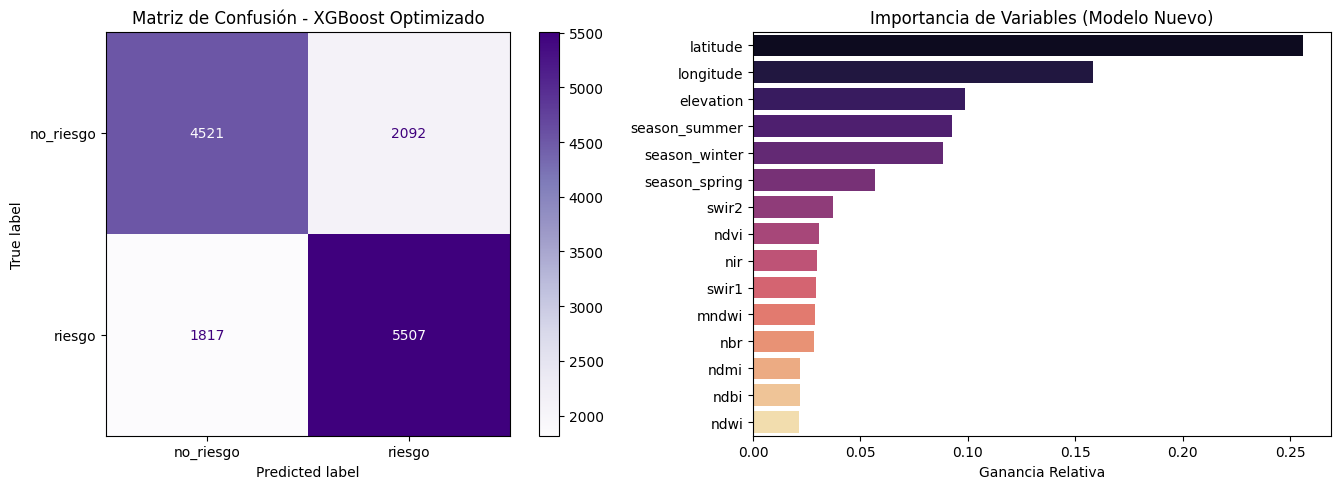

In [13]:
# ============================================================
# 5. HYPERPARAMETER TUNING (Randomized Search)
# ============================================================

# Since we stripped down the feature space, optimal depth and regularization are vital.
param_dist = {
    'n_estimators': [300, 500, 800],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2, 0.4],
    'reg_alpha': [0, 0.1, 1, 5],
    'reg_lambda': [1, 2, 5]
}

cv_strategy = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

print("\nIniciando optimización por búsqueda aleatoria...")
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(random_state=42, n_jobs=-1, eval_metric="logloss"),
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

print("\nMejores parámetros encontrados:")
for param, value in xgb_search.best_params_.items():
    print(f" -> {param}: {value}")

# ============================================================
# 6. EVALUATION OF OPTIMIZED MODEL
# ============================================================

y_pred_opt = best_xgb.predict(X_test)
y_probs_opt = best_xgb.predict_proba(X_test)[:, 1]

print("\n" + "="*55)
print("REPORTE DE CLASIFICACIÓN (MODELO OPTIMIZADO)")
print("="*55)
print(classification_report(y_test, y_pred_opt, target_names=["no_riesgo", "riesgo"]))
auc_opt = roc_auc_score(y_test, y_probs_opt)
print(f"Área Bajo la Curva ROC (AUC-ROC) Optimizado: {auc_opt:.4f}")

# ============================================================
# 7. VISUALIZATION
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no_riesgo", "riesgo"])
disp.plot(ax=ax[0], cmap="Purples", values_format="d")
ax[0].set_title("Matriz de Confusión - XGBoost Optimizado")

# Feature Importance
importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]

sns.barplot(x=importances[indices], y=np.array(UPDATED_FEATURES)[indices], ax=ax[1], palette="magma")
ax[1].set_title("Importancia de Variables (Modelo Nuevo)")
ax[1].set_xlabel("Ganancia Relativa")

plt.tight_layout()
plt.show()